In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [10]:
ExcelFile= pd.ExcelFile("ipo_pivot.xlsx")

In [11]:
ExcelFile.sheet_names

['outcome_category_count',
 'Date_listing_gain',
 'Date_count_ipo',
 'Demand_gain_count',
 'Demand_success',
 'Qib_gains_count',
 'QIB_SUCCESS',
 'Size_gains_success',
 'Driver_gains_success',
 'Research_findings',
 'Dashboard_data',
 'Fact']

In [12]:
df = pd.read_excel(
    "ipo_pivot.xlsx",
    sheet_name="Fact"
)

In [13]:
df

,Date,Ipo_name,Profile,Issue_size,Qib,Hni,Rii,Total_subscription,Issue,Listing_open,Listing_close,Listing_gains_percent,Outcome_category,Subscription_category,Issue_size_category,Institutional_confidence,Subscription_mismatch
0,2021-07-29,Tatva Chintan,https://www.moneycontrol.com/ipo/tatva-chintan...,500.00,2.55,9.78,13.36,9.50,1083,2111.80,2310.25,113.32,Blockbuster Success,Medium Demand,Medium,Moderate Institutional Interest,Retail Driven
1,2021-07-23,Zomato,https://www.moneycontrol.com/ipo/zomato_Z01.html,9375.00,51.79,32.96,7.45,38.25,76,115.00,125.85,65.59,Blockbuster Success,High Demand,Large,Very High Institutional Interest,Institution Driven
2,2021-07-19,Clean Science,https://www.moneycontrol.com/ipo/clean-science...,1546.00,156.37,206.43,9.00,93.41,900,1784.40,1585.20,76.13,Blockbuster Success,High Demand,Medium,Very High Institutional Interest,Institution Driven
3,2021-07-19,G R Infra,https://www.moneycontrol.com/ipo/g-r-infra_I13...,963.28,93.18,73.01,4.89,43.48,837,1700.00,1746.80,108.70,Blockbuster Success,High Demand,Medium,Very High Institutional Interest,Institution Driven
4,2021-07-07,India Pesticide,https://www.moneycontrol.com/ipo/india-pestici...,800.00,2.64,1.36,4.40,3.25,296,360.00,335.45,13.33,Moderate Success,Low Demand,Medium,Moderate Institutional Interest,Retail Driven
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,2010-02-19,Thangamayil,https://www.moneycontrol.com/ipo/thangamayil_T...,0.00,0.52,1.52,2.26,1.12,75,70.00,71.10,-5.20,Loss Making,Low Demand,Small,Low Institutional Interest,Retail Driven
260,2010-02-15,Vascon Engineer,https://www.moneycontrol.com/ipo/vascon-engine...,199.80,1.12,3.65,0.62,1.22,165,155.90,146.38,-11.28,Loss Making,Low Demand,Small,Moderate Institutional Interest,Institution Driven
261,2010-02-15,Syncom Health,https://www.moneycontrol.com/ipo/syncom-health...,56.25,0.99,16.60,6.25,5.17,75,88.00,87.85,17.13,Moderate Success,Medium Demand,Small,Low Institutional Interest,Retail Driven
262,2010-08-02,Jubilant Food,https://www.moneycontrol.com/ipo/jubilant-food...,328.70,59.39,51.95,3.79,31.11,145,160.00,114.50,-21.03,Disaster,High Demand,Small,Very High Institutional Interest,Institution Driven


In [14]:
df.head()

,Date,Ipo_name,Profile,Issue_size,Qib,Hni,Rii,Total_subscription,Issue,Listing_open,Listing_close,Listing_gains_percent,Outcome_category,Subscription_category,Issue_size_category,Institutional_confidence,Subscription_mismatch
0,2021-07-29,Tatva Chintan,https://www.moneycontrol.com/ipo/tatva-chintan...,500.00,2.55,9.78,13.36,9.50,1083,2111.8,2310.25,113.32,Blockbuster Success,Medium Demand,Medium,Moderate Institutional Interest,Retail Driven
1,2021-07-23,Zomato,https://www.moneycontrol.com/ipo/zomato_Z01.html,9375.00,51.79,32.96,7.45,38.25,76,115.0,125.85,65.59,Blockbuster Success,High Demand,Large,Very High Institutional Interest,Institution Driven
2,2021-07-19,Clean Science,https://www.moneycontrol.com/ipo/clean-science...,1546.00,156.37,206.43,9.00,93.41,900,1784.4,1585.20,76.13,Blockbuster Success,High Demand,Medium,Very High Institutional Interest,Institution Driven
3,2021-07-19,G R Infra,https://www.moneycontrol.com/ipo/g-r-infra_I13...,963.28,93.18,73.01,4.89,43.48,837,1700.0,1746.80,108.70,Blockbuster Success,High Demand,Medium,Very High Institutional Interest,Institution Driven
4,2021-07-07,India Pesticide,https://www.moneycontrol.com/ipo/india-pestici...,800.00,2.64,1.36,4.40,3.25,296,360.0,335.45,13.33,Moderate Success,Low Demand,Medium,Moderate Institutional Interest,Retail Driven


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      264 non-null    datetime64[ns]
 1   Ipo_name                  264 non-null    object        
 2   Profile                   264 non-null    object        
 3   Issue_size                264 non-null    float64       
 4   Qib                       264 non-null    float64       
 5   Hni                       264 non-null    float64       
 6   Rii                       264 non-null    float64       
 7   Total_subscription        264 non-null    float64       
 8   Issue                     264 non-null    int64         
 9   Listing_open              264 non-null    float64       
 10  Listing_close             264 non-null    float64       
 11  Listing_gains_percent     264 non-null    float64       
 12  Outcome_category      

In [16]:
df.columns.tolist()

['Date',
 'Ipo_name',
 'Profile',
 'Issue_size',
 'Qib',
 'Hni',
 'Rii',
 'Total_subscription',
 'Issue',
 'Listing_open',
 'Listing_close',
 'Listing_gains_percent',
 'Outcome_category',
 'Subscription_category',
 'Issue_size_category',
 'Institutional_confidence',
 'Subscription_mismatch']

In [17]:
df[['Qib','Hni','Rii','Total_subscription','Listing_gains_percent']].describe()

,Qib,Hni,Rii,Total_subscription,Listing_gains_percent
count,264.000000,264.000000,264.000000,264.000000,264.000000
mean,23.732841,68.798561,7.388371,25.944886,4.290871
std,36.880595,136.513479,11.837761,45.444680,46.343783
min,0.000000,0.000000,0.000000,0.000000,-97.150000
25%,1.130000,1.210000,1.297500,1.570000,-11.755000
50%,4.670000,5.075000,3.380000,4.845000,1.355000
75%,32.505000,65.112500,8.392500,33.412500,25.635000
max,176.850000,958.070000,77.930000,277.280000,153.500000


In [18]:
corr_matrix = df[['Qib','Hni','Rii','Total_subscription','Listing_gains_percent']].corr()
corr_matrix

,Qib,Hni,Rii,Total_subscription,Listing_gains_percent
Qib,1.000000,0.764483,0.428325,0.799697,0.408704
Hni,0.764483,1.000000,0.621727,0.947598,0.428810
Rii,0.428325,0.621727,1.000000,0.724700,0.446565
Total_subscription,0.799697,0.947598,0.724700,1.000000,0.496516
Listing_gains_percent,0.408704,0.428810,0.446565,0.496516,1.000000


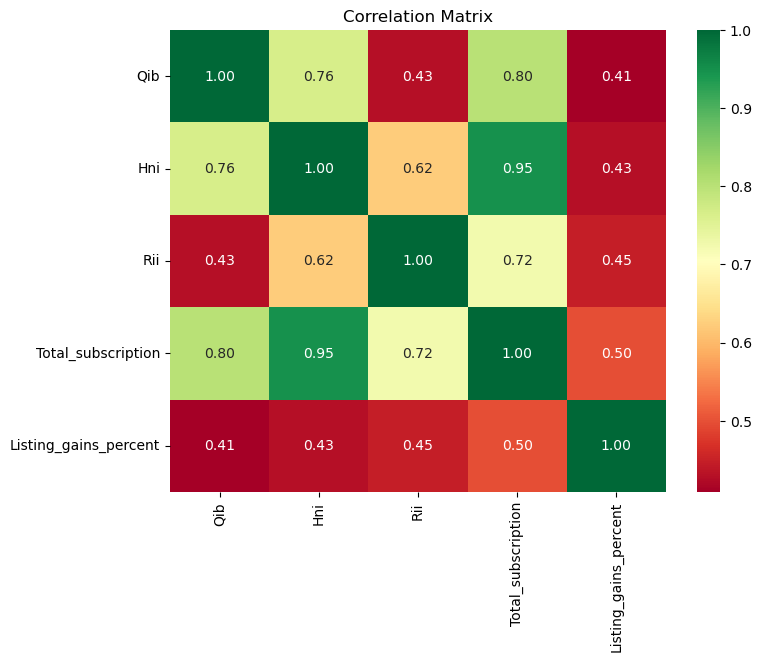

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,annot=True,cmap='RdYlGn',fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

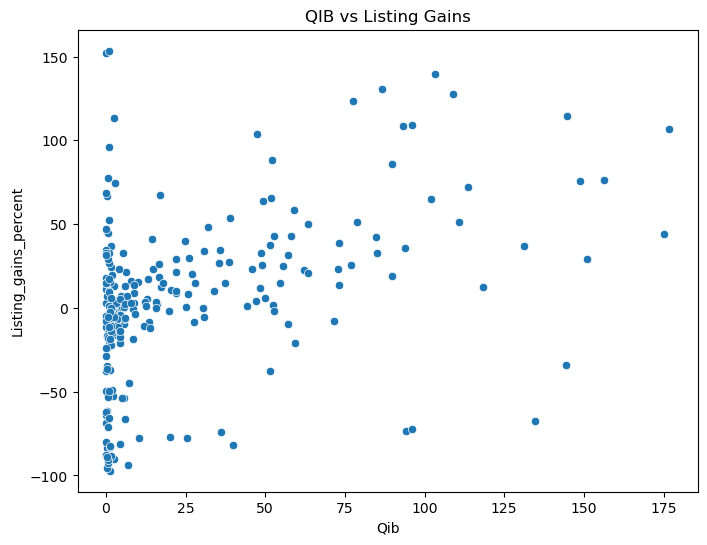

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Qib',
    y='Listing_gains_percent'
)

plt.title('QIB vs Listing Gains')
plt.show()

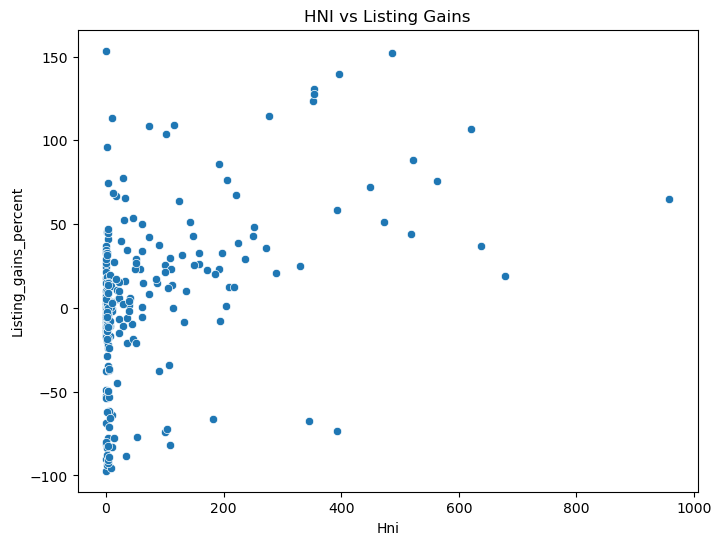

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Hni',
    y='Listing_gains_percent'
)

plt.title('HNI vs Listing Gains')
plt.show()

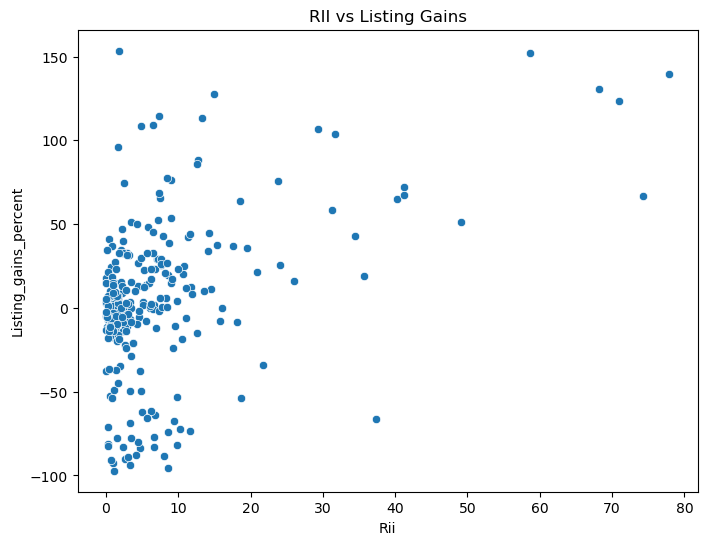

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Rii',
    y='Listing_gains_percent'
)

plt.title('RII vs Listing Gains')
plt.show()

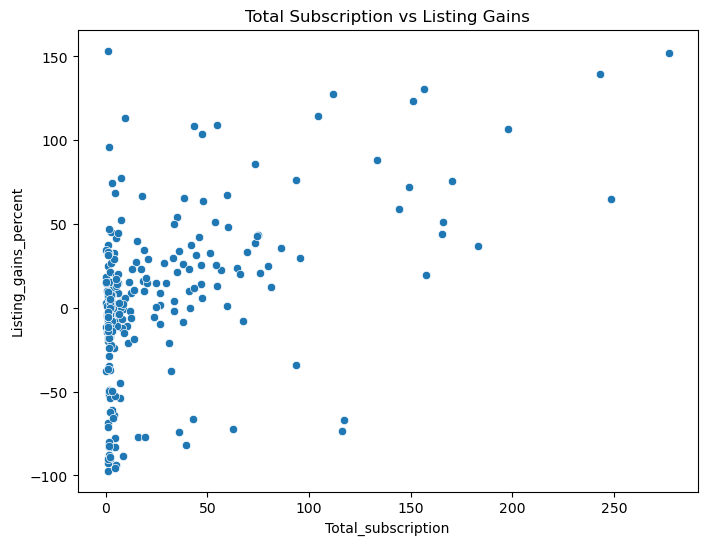

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Total_subscription',
    y='Listing_gains_percent'
)

plt.title('Total Subscription vs Listing Gains')
plt.show()

In [25]:
high_demand = df[
    df['Subscription_category'] == 'High Demand'
]['Listing_gains_percent']

low_demand = df[
    df['Subscription_category'] == 'Low Demand'
]['Listing_gains_percent']

In [26]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    high_demand,
    low_demand,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 6.931415774347884
P-Value: 1.1816528576795053e-10


In [27]:
institution_driven = df[
    df['Subscription_mismatch'] == 'Institution Driven'
]['Listing_gains_percent']

retail_driven = df[
    df['Subscription_mismatch'] == 'Retail Driven'
]['Listing_gains_percent']

In [28]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    institution_driven,
    retail_driven,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 2.5363041325187448
P-Value: 0.012195939070415177


In [29]:
print("Institution Driven IPOs:", len(institution_driven))
print("Retail Driven IPOs:", len(retail_driven))

Institution Driven IPOs: 175
Retail Driven IPOs: 89


In [30]:
small = df[
    df['Issue_size_category'] == 'Small'
]['Listing_gains_percent']

medium = df[
    df['Issue_size_category'] == 'Medium'
]['Listing_gains_percent']

large = df[
    df['Issue_size_category'] == 'Large'
]['Listing_gains_percent']

In [31]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    small,
    medium,
    large
)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 5.089080024099688
P-Value: 0.006789637548632918


In [32]:
print("Small:", len(small))
print("Medium:", len(medium))
print("Large:", len(large))

Small: 149
Medium: 89
Large: 26


In [33]:
df[['Qib',
    'Hni',
    'Rii',
    'Total_subscription',
    'Issue_size',
    'Listing_gains_percent']].describe()

,Qib,Hni,Rii,Total_subscription,Issue_size,Listing_gains_percent
count,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000
mean,23.732841,68.798561,7.388371,25.944886,978.718106,4.290871
std,36.880595,136.513479,11.837761,45.444680,1884.758112,46.343783
min,0.000000,0.000000,0.000000,0.000000,0.000000,-97.150000
25%,1.130000,1.210000,1.297500,1.570000,144.250000,-11.755000
50%,4.670000,5.075000,3.380000,4.845000,441.225000,1.355000
75%,32.505000,65.112500,8.392500,33.412500,903.187500,25.635000
max,176.850000,958.070000,77.930000,277.280000,15475.000000,153.500000


In [34]:
df['log_qib'] = np.log1p(df['Qib'])
df['log_hni'] = np.log1p(df['Hni'])
df['log_rii'] = np.log1p(df['Rii'])
df['log_total_subscription'] = np.log1p(df['Total_subscription'])
df['log_issue_size'] = np.log1p(df['Issue_size'])

In [35]:
df[
    [
        'log_qib',
        'log_hni',
        'log_rii',
        'log_total_subscription',
        'log_issue_size'
    ]
].describe()

,log_qib,log_hni,log_rii,log_total_subscription,log_issue_size
count,264.000000,264.000000,264.000000,264.000000,264.000000
mean,2.094057,2.480717,1.582482,2.203815,5.905184
std,1.543654,1.965128,0.981911,1.449874,1.479266
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.756122,0.792993,0.831676,0.943906,4.978416
50%,1.735188,1.804182,1.477038,1.765557,6.091803
75%,3.511435,4.189094,2.239909,3.538420,6.807030
max,5.180940,6.865964,4.368561,5.628628,9.647046


In [36]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [37]:
import statsmodels.api as sm

In [38]:
X = df[
    [
        'log_total_subscription',
        'log_issue_size'
    ]
]

y = df['Listing_gains_percent']

In [39]:
X = sm.add_constant(X)

In [40]:
model = sm.OLS(y, X).fit()

In [41]:
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     Listing_gains_percent   R-squared:                       0.214
Model:                               OLS   Adj. R-squared:                  0.208
Method:                    Least Squares   F-statistic:                     35.46
Date:                   Tue, 23 Jun 2026   Prob (F-statistic):           2.38e-14
Time:                           17:20:02   Log-Likelihood:                -1355.1
No. Observations:                    264   AIC:                             2716.
Df Residuals:                        261   BIC:                             2727.
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [42]:
X = df[
    [
        'log_qib',
        'log_hni',
        'log_rii',
        'log_issue_size'
    ]
]

y = df['Listing_gains_percent']

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                              OLS Regression Results                             
Dep. Variable:     Listing_gains_percent   R-squared:                       0.210
Model:                               OLS   Adj. R-squared:                  0.198
Method:                    Least Squares   F-statistic:                     17.23
Date:                   Tue, 23 Jun 2026   Prob (F-statistic):           1.51e-12
Time:                           17:20:02   Log-Likelihood:                -1355.7
No. Observations:                    264   AIC:                             2721.
Df Residuals:                        259   BIC:                             2739.
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const         

In [43]:
df['institution_driven_dummy'] = (
    df['Subscription_mismatch']
    == 'Institution Driven'
).astype(int)

In [44]:
X = df[
    [
        'log_total_subscription',
        'log_issue_size',
        'institution_driven_dummy'
    ]
]

y = df['Listing_gains_percent']

X = sm.add_constant(X)

model3 = sm.OLS(y, X).fit()

print(model3.summary())

                              OLS Regression Results                             
Dep. Variable:     Listing_gains_percent   R-squared:                       0.223
Model:                               OLS   Adj. R-squared:                  0.214
Method:                    Least Squares   F-statistic:                     24.87
Date:                   Tue, 23 Jun 2026   Prob (F-statistic):           3.51e-14
Time:                           17:20:02   Log-Likelihood:                -1353.5
No. Observations:                    264   AIC:                             2715.
Df Residuals:                        260   BIC:                             2729.
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [45]:
nifty = pd.read_csv("NIFTY_2010_2021.csv")

In [46]:
nifty

,Date,Open,High,Low,Close,Shares Traded,Turnover (Rs. Cr)
0,04-Jan-2010,5200.90,5238.45,5167.10,5232.20,148652424,6531.61
1,05-Jan-2010,5277.15,5288.35,5242.40,5277.90,240844424,7969.62
2,06-Jan-2010,5278.15,5310.85,5260.05,5281.80,216147837,7892.60
3,07-Jan-2010,5281.80,5302.55,5244.75,5263.10,181246734,6890.99
4,08-Jan-2010,5264.25,5276.75,5234.70,5244.75,201910800,7777.04
...,...,...,...,...,...,...,...
2868,26-Jul-2021,15849.30,15893.35,15797.00,15824.45,267076679,19487.18
2869,27-Jul-2021,15860.50,15881.55,15701.00,15746.45,311012065,26117.34
2870,28-Jul-2021,15761.55,15767.50,15513.45,15709.40,318601589,26090.48
2871,29-Jul-2021,15762.70,15817.35,15737.80,15778.45,401584915,29460.54


In [47]:
nifty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2873 entries, 0 to 2872
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2873 non-null   object 
 1   Open               2873 non-null   float64
 2   High               2873 non-null   float64
 3   Low                2873 non-null   float64
 4   Close              2873 non-null   float64
 5   Shares Traded      2873 non-null   int64  
 6   Turnover (Rs. Cr)  2873 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 157.2+ KB


In [48]:
df['Date'] = pd.to_datetime(df['Date'])

In [49]:
nifty['Date'] = pd.to_datetime(
    nifty['Date'],
    dayfirst=True
)

In [50]:
df = df.sort_values('Date')

nifty = nifty.sort_values('Date')

In [51]:
print(df['Date'].min())
print(df['Date'].max())

print(nifty['Date'].min())
print(nifty['Date'].max())

2010-01-07 00:00:00
2021-07-29 00:00:00
2010-01-04 00:00:00
2021-07-30 00:00:00


In [52]:
nifty = nifty[['Date', 'Close']]
nifty.head()

,Date,Close
0,2010-01-04,5232.20
1,2010-01-05,5277.90
2,2010-01-06,5281.80
3,2010-01-07,5263.10
4,2010-01-08,5244.75


In [53]:
nifty = nifty.sort_values('Date')

def get_nifty_return(ipo_date, days):
    
    current_row = nifty[nifty['Date'] <= ipo_date]

    if len(current_row) == 0:
        return np.nan

    current_close = current_row.iloc[-1]['Close']

    past_date = ipo_date - pd.Timedelta(days=days)

    past_row = nifty[nifty['Date'] <= past_date]

    if len(past_row) == 0:
        return np.nan

    past_close = past_row.iloc[-1]['Close']

    return ((current_close - past_close) / past_close) * 100

In [54]:
df['Nifty_30D_Return'] = df['Date'].apply(
    lambda x: get_nifty_return(x, 30)
)

In [55]:
df['Nifty_90D_Return'] = df['Date'].apply(
    lambda x: get_nifty_return(x, 90)
)

In [56]:
df[
    [
        'Date',
        'Nifty_30D_Return',
        'Nifty_90D_Return'
    ]
].head(10)

,Date,Nifty_30D_Return,Nifty_90D_Return
237,2010-01-07,NaN,NaN
228,2010-01-10,NaN,NaN
261,2010-02-15,-8.572598,NaN
260,2010-02-15,-8.572598,NaN
259,2010-02-19,-7.216041,NaN
258,2010-02-23,-3.295274,NaN
257,2010-02-24,-2.981290,NaN
256,2010-02-24,-2.981290,NaN
255,2010-02-25,-2.958326,NaN
263,2010-03-02,2.764208,NaN


In [57]:
df[
    [
        'Nifty_30D_Return',
        'Nifty_90D_Return'
    ]
].describe()

,Nifty_30D_Return,Nifty_90D_Return
count,262.000000,250.000000
mean,0.497174,3.238779
std,4.598663,7.736525
min,-24.072828,-24.394575
25%,-1.967251,-1.276374
50%,0.633958,3.825175
75%,3.361883,8.073675
max,12.161916,24.424787


In [58]:
df[
    [
       
        'Nifty_90D_Return',
        'Listing_gains_percent'
    ]
].corr()

,Nifty_90D_Return,Listing_gains_percent
Nifty_90D_Return,1.000000,0.228612
Listing_gains_percent,0.228612,1.000000


In [59]:
reg_df = df[
    [
        'Listing_gains_percent',
        'log_total_subscription',
        'log_issue_size',
        'Nifty_90D_Return',
        
    ]
].dropna()

In [60]:
X = reg_df[
    [
        'log_total_subscription',
        'log_issue_size',
        'Nifty_90D_Return'
    ]
]

y = reg_df['Listing_gains_percent']

X = sm.add_constant(X)

model4 = sm.OLS(y, X).fit()

print(model4.summary())

                              OLS Regression Results                             
Dep. Variable:     Listing_gains_percent   R-squared:                       0.219
Model:                               OLS   Adj. R-squared:                  0.210
Method:                    Least Squares   F-statistic:                     23.02
Date:                   Tue, 23 Jun 2026   Prob (F-statistic):           3.60e-13
Time:                           17:20:04   Log-Likelihood:                -1283.8
No. Observations:                    250   AIC:                             2576.
Df Residuals:                        246   BIC:                             2590.
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [61]:
X = reg_df[
    [
        'log_total_subscription',
        'log_issue_size',
        'Nifty_90D_Return'
    ]
]

y = reg_df['Listing_gains_percent']

X = sm.add_constant(X)

model4 = sm.OLS(y, X).fit()

print(model4.summary())

                              OLS Regression Results                             
Dep. Variable:     Listing_gains_percent   R-squared:                       0.219
Model:                               OLS   Adj. R-squared:                  0.210
Method:                    Least Squares   F-statistic:                     23.02
Date:                   Tue, 23 Jun 2026   Prob (F-statistic):           3.60e-13
Time:                           17:20:04   Log-Likelihood:                -1283.8
No. Observations:                    250   AIC:                             2576.
Df Residuals:                        246   BIC:                             2590.
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [63]:
df.to_excel(
    "ipo_dashboard_data.xlsx",
    index=False
)